# 01 — Price Formation

## What Does "Price" Actually Mean?

Chúng ta thường nói:

- Giá tăng
- Giá giảm
- Thị trường phản ứng với tin tức

Nhưng "giá" thực chất không phải một thực thể độc lập tồn tại sẵn.

Giá là kết quả của:

- Order flow
- Matching mechanism
- Liquidity consumption

Notebook này chỉ tập trung vào một câu hỏi:

> Giá được hình thành như thế nào trong order book?

Không dùng dữ liệu thật.
Không dùng lý thuyết học thuật nặng.
Chỉ dùng cơ chế mô phỏng để quan sát trực tiếp.

In [9]:
from src.structure import OrderBook
from src.utils import plot_price_series
import numpy as np
import matplotlib.pyplot as plt

## 1. The Limit Order Book

Giá không phải là một con số duy nhất.

Thị trường tồn tại dưới dạng:

- Best bid (giá cao nhất người mua sẵn sàng trả)
- Best ask (giá thấp nhất người bán sẵn sàng bán)

Mid price chỉ là trung bình của hai mức này.

Giá giao dịch thực sự chỉ xuất hiện khi có market order xảy ra.
Thị trường không có một “giá duy nhất”.
Nó có một dải giá sẵn sàng giao dịch.

In [2]:
book = OrderBook(mid_price=100)

print("Best Bid:", book.best_bid())
print("Best Ask:", book.best_ask())
print("Mid Price:", book.mid())

Best Bid: 99.9
Best Ask: 100.1
Mid Price: 100.0


Mid price không phải là giá được giao dịch.

Nó chỉ là một đại lượng tham chiếu.

Giá thực sự là mức giá mà một market order được khớp.

In [6]:
book = OrderBook(mid_price=100)

small_trade = book.execute_market_order(side="buy", quantity=50)
small_trade

{'avg_price': 100.1, 'filled': 50, 'remaining': 0, 'new_mid': 100.0}

Khi order nhỏ:

- Nó chỉ ăn một phần level đầu tiên
- Spread không thay đổi
- Mid price không thay đổi
- Nhưng execution price cao hơn mid

Không có tin tức. Chỉ có thanh khoản bị tiêu thụ.

Execution price ≠ Mid price.

Ngay cả khi mid không thay đổi,
trader vẫn chịu implicit cost.

Chi phí này đến từ cấu trúc spread,
không phải từ biến động thị trường.

In [7]:
book = OrderBook(mid_price=100)

large_trade = book.execute_market_order(side="buy", quantity=400)
large_trade

{'avg_price': 100.25,
 'filled': 400.0,
 'remaining': 0.0,
 'new_mid': 100.19999999999999}

Khi order lớn:

- Nó ăn nhiều level trong order book
- Execution price cao hơn đáng kể so với mid ban đầu
- Best ask bị đẩy lên
- Mid price dịch chuyển

Điều này cho thấy:

> Impact không chỉ là chi phí thực thi.
Impact có thể thay đổi chính cấu trúc thị trường.

Large order tạo ra hai loại impact:

Execution impact:
avg_price - mid ban đầu

Structural impact:
mid mới - mid cũ

Execution impact phản ánh chi phí bạn trả.
Structural impact phản ánh thị trường đã bị thay đổi.

Nếu structural impact lớn,
bạn không chỉ mua ở giá cao —
bạn đã đẩy thị trường lên.

## 2. Slippage Is Structural

Order lớn:

- Ăn nhiều level
- Average execution price tăng mạnh
- Mid price nhảy xa

Slippage không phải lỗi hệ thống.
Nó là hệ quả tự nhiên của thanh khoản hữu hạn.

Kích thước quan trọng hơn tín hiệu.

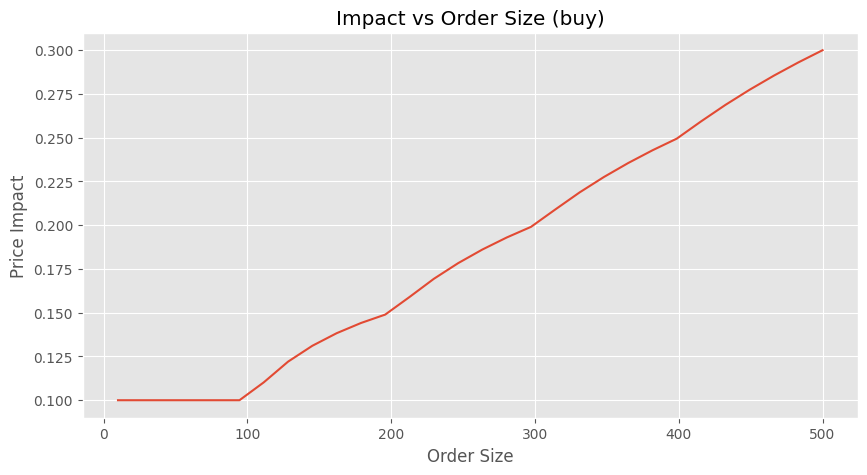

In [12]:
def plot_impact_curve(
    mid_price=100,
    side="buy",
    min_size=10,
    max_size=500,
    n_points=30
):
    sizes = np.linspace(min_size, max_size, n_points)
    impacts = []

    for size in sizes:
        book = OrderBook(mid_price=mid_price)
        result = book.execute_market_order(side=side, quantity=size)

        if result["avg_price"] is None:
            impacts.append(np.nan)
        else:
            if side == "buy":
                impacts.append(result["avg_price"] - mid_price)
            else:
                impacts.append(mid_price - result["avg_price"])

    plt.plot(sizes, impacts)
    plt.xlabel("Order Size")
    plt.ylabel("Price Impact")
    plt.title(f"Impact vs Order Size ({side})")
    plt.show()

plot_impact_curve()

## Interpretation of the Impact Curve

Biểu đồ cho thấy mối quan hệ giữa kích thước lệnh (order size) và mức độ ảnh hưởng lên giá (price impact).

### 1. Vùng phẳng ban đầu

Ở các kích thước nhỏ, impact gần như không thay đổi.
Điều này xảy ra vì toàn bộ lệnh vẫn được khớp tại level đầu tiên của order book.

Thanh khoản tại best ask vẫn còn đủ để hấp thụ lệnh,
nên cấu trúc thị trường chưa thay đổi.

Impact trong vùng này chủ yếu là spread cost,
không phải structural shift.

---

### 2. Điểm gãy tại ngưỡng thanh khoản

Khi kích thước lệnh vượt quá depth của level 1,
lệnh bắt đầu ăn sang level 2.

Tại thời điểm này:

- Average execution price tăng
- Best ask thay đổi
- Mid price dịch chuyển

Đây là lúc structural impact bắt đầu xuất hiện.

---

### 3. Tính phân tầng của thanh khoản

Đường cong tăng dần theo từng bước vì order book được tổ chức theo level.

Mỗi khi một level bị tiêu thụ hết,
giá phải nhảy lên mức tiếp theo.

Impact do đó không đến từ tin tức,
mà đến từ cấu trúc phân tầng của thanh khoản.

---

### 4. Insight quan trọng

Impact không phụ thuộc vào bản thân con số tuyệt đối của order,
mà phụ thuộc vào kích thước tương đối so với liquidity.

Cùng một lệnh,
nhưng trong môi trường depth dày hơn,
impact sẽ nhỏ hơn đáng kể.

---

### 5. Kết luận

Biểu đồ này thực chất là một đường cung vi mô (micro supply curve).

Order size càng lớn,
bạn càng phải leo lên các mức giá cao hơn.

Không có "giảm giá khi mua nhiều" trong thị trường order-driven.
Chỉ có thanh khoản hữu hạn và cấu trúc giá phân tầng.

## 3. Impact Is Nonlinear

Impact không tăng tuyến tính theo size.

Khi depth gần cạn:

- Impact tăng nhanh hơn
- Giá trở nên nhạy cảm

Điều này cực kỳ quan trọng:
> Risk không tăng tuyến tính theo position size.

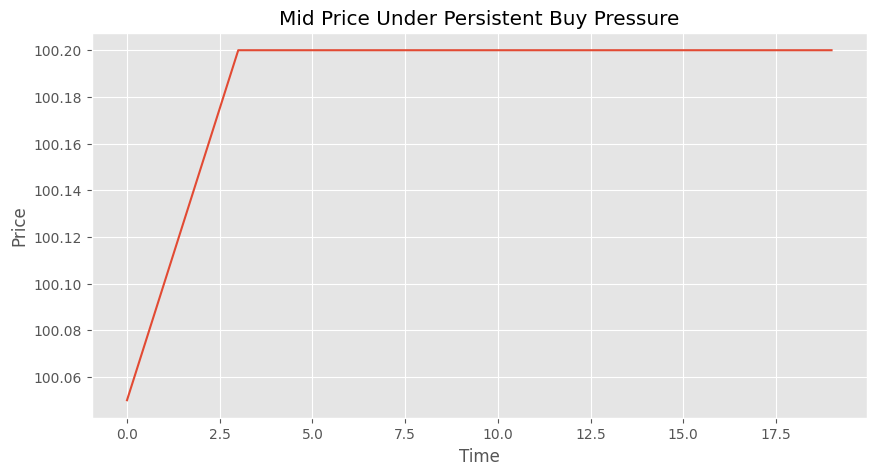

In [11]:
book = OrderBook(mid_price=100)

mid_prices = []

for _ in range(20):
    book.execute_market_order(side="buy", quantity=100)
    mid_prices.append(book.mid())

plot_price_series(np.array(mid_prices), title="Mid Price Under Persistent Buy Pressure")

## Interpretation: Mid Price Under Persistent Buy Pressure

Biểu đồ cho thấy diễn biến của mid price khi xuất hiện áp lực mua liên tục (persistent buy pressure).

### 1. Giai đoạn đầu: phản ứng nhanh

Ở những bước đầu tiên, mid price tăng rõ rệt.

Điều này xảy ra vì:

- Các level ask gần nhất bị tiêu thụ
- Best ask tăng
- Mid price dịch chuyển lên

Trong giai đoạn này, depth vẫn còn đủ nhưng đang bị rút nhanh.

---

### 2. Giai đoạn sau: bão hòa tạm thời

Sau khi các level gần bị ăn hết, giá ổn định ở mức cao hơn.

Điều này cho thấy:

- Áp lực mua không còn đủ lớn để tiếp tục quét thêm level
- Hoặc thanh khoản mới đã được bổ sung ở mức giá cao hơn

Mid price không tăng liên tục một cách mượt mà,
mà tăng theo từng bước khi thanh khoản bị phá vỡ.

---

## Impact Is Nonlinear

Impact không tăng tuyến tính theo size.

Lý do:

- Order book có cấu trúc phân tầng
- Thanh khoản không phân bố đều
- Khi depth gần cạn, mỗi đơn vị order thêm sẽ gây tác động lớn hơn

Nghĩa là:

Small size → tác động nhỏ
Large size → tác động tăng nhanh

Đây là tính phi tuyến (nonlinearity).

---

## Tại sao điều này quan trọng?

Risk không tăng tuyến tính theo position size.

Nếu bạn tăng position gấp đôi:

- Execution cost có thể tăng hơn gấp đôi
- Slippage có thể bùng nổ
- Liquidity có thể biến mất

Trong môi trường thanh khoản mỏng,
một thay đổi nhỏ về size có thể gây biến động lớn về giá.

---

## Structural Insight

Giá không phản ứng đều theo khối lượng.

Nó phản ứng mạnh khi thanh khoản bị rút gần hết.

Do đó:

Thị trường ổn định khi liquidity dày.
Thị trường mong manh khi liquidity mỏng.

Nonlinear impact chính là nguồn gốc của tail risk.

## 4. Price Moves Without News

Trong mô phỏng này:

- Không có fundamental
- Không có behavioral bias
- Không có thông tin mới

Chỉ có imbalance.

Vậy mà giá vẫn tăng.

Giá thay đổi vì imbalance,
không cần tin tức.

## 5. The Illusion of Close Price

Close price chỉ là giao dịch cuối cùng.

Nó không đại diện cho:

- Tổng liquidity
- Tình trạng depth
- Áp lực ẩn trong order book

Backtest dựa trên close price bỏ qua cấu trúc thanh khoản.

## Key Structural Insights

1. Price không tồn tại độc lập.
2. Mid price chỉ là hệ quả của bid/ask.
3. Slippage là cấu trúc, không phải lỗi.
4. Impact là phi tuyến.
5. Order size quan trọng hơn signal.
6. Imbalance đủ lớn có thể tự tạo trend.

Notebook này chỉ phân tích cơ chế cơ học.

Các notebook sau sẽ mở rộng:

- Liquidity depth
- Market maker behavior
- Leverage constraint
- Liquidation cascade